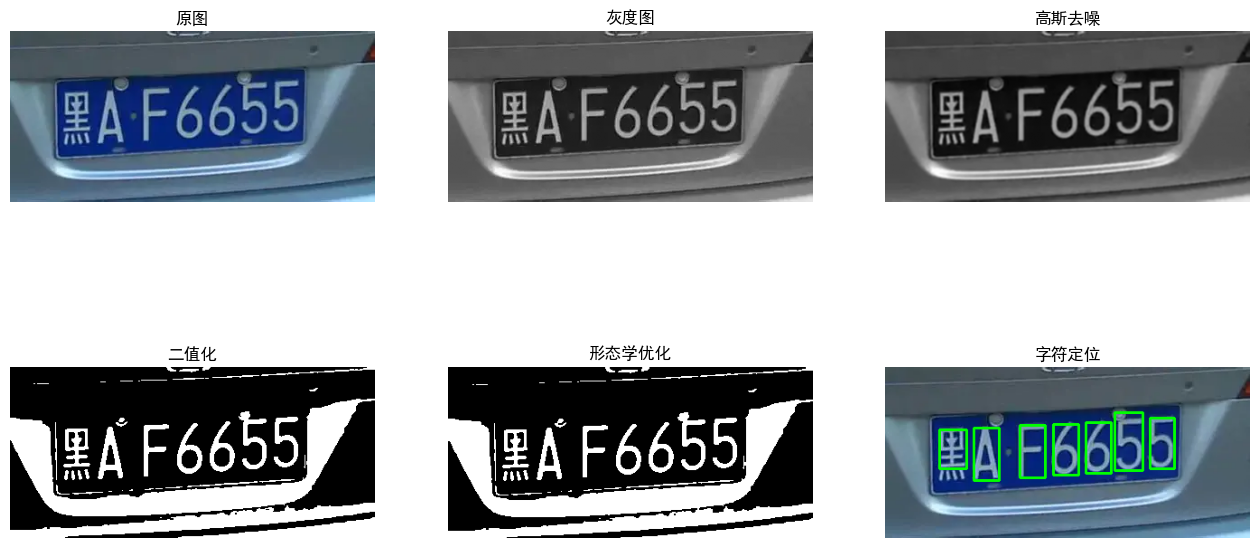

分割字符数： 7


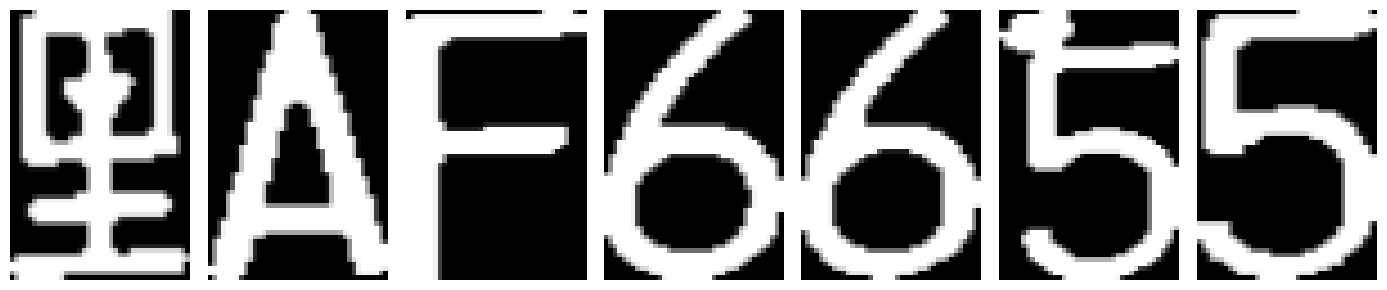

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 绘图显示设置
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
%matplotlib inline

# 读取车牌图像
img = cv2.imread("car_plate.jpg")

if img is not None:
    # 灰度化处理
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 高斯模糊去噪
    blur = cv2.GaussianBlur(gray, (3, 3), 0)

    # 自动阈值二值化
    ret, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 形态学闭运算，填充字符间隙
    kernel = np.ones((2, 2), np.uint8)
    th_clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    # 查找图像轮廓
    contours, hierarchy = cv2.findContours(th_clean, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    char_list = []
    h_img, w_img = th_clean.shape

    # 筛选符合字符尺寸的轮廓
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if 0.2 * h_img < h < 0.9 * h_img and 0.1 < w/h < 1.2 and w < 0.2 * w_img:
            is_duplicate = False
            for (cx, cy, cw, ch) in char_list:
                if abs(x - cx) < 5 and abs(y - cy) < 5:
                    is_duplicate = True
                    break
            if not is_duplicate:
                char_list.append((x, y, w, h))

    # 按从左到右排序
    char_list = sorted(char_list, key=lambda ch: ch[0])

    # ==================== 显示处理过程 ====================
    plt.figure(figsize=(16,8))

    plt.subplot(2,3,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("原图")
    plt.axis("off")

    plt.subplot(2,3,2)
    plt.imshow(gray, cmap="gray")
    plt.title("灰度图")
    plt.axis("off")

    plt.subplot(2,3,3)
    plt.imshow(blur, cmap="gray")
    plt.title("高斯去噪")
    plt.axis("off")

    plt.subplot(2,3,4)
    plt.imshow(thresh, cmap="gray")
    plt.title("二值化")
    plt.axis("off")

    plt.subplot(2,3,5)
    plt.imshow(th_clean, cmap="gray")
    plt.title("形态学优化")
    plt.axis("off")

    # 画出字符框
    img_box = img.copy()
    for x,y,w,h in char_list:
        cv2.rectangle(img_box,(x,y),(x+w,y+h),(0,255,0),2)

    plt.subplot(2,3,6)
    plt.imshow(cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB))
    plt.title("字符定位")
    plt.axis("off")

    plt.show()

    # ==================== 最后：横向显示单个字符 ====================
    print("分割字符数：", len(char_list))

    if len(char_list) > 0:
        plt.figure(figsize=(len(char_list)*2, 3))
        for i, (x, y, w, h) in enumerate(char_list):
            char_img = th_clean[y:y+h, x:x+w]
            char_img = cv2.resize(char_img, (40, 60))

            plt.subplot(1, len(char_list), i+1)
            plt.imshow(char_img, cmap="gray")
            plt.axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("图片读取失败")